# 03 - Layer A Text Retrieval Debug

Notebook này dùng để **kiểm tra retrieval văn bản của Layer A**. Phần triển khai dài được thu gọn mặc định; các cell thực thi vẫn giữ output cần thiết cho debug.

### BƯỚC 1: Setup Tối Thiểu

- **Tác dụng chính:** Notebook này dùng để kiểm tra retrieval văn bản của Layer A. Phần triển khai dài được thu gọn mặc định; các cell thực thi vẫn giữ output cần thiết cho debug.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `find_chatbot_fashion_root`, `CHATBOT_FASHION_DIR` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [1]:
import math

import re

import sys

import unicodedata

from collections import Counter

from pathlib import Path

from langchain_core.documents import Document

from langchain_qdrant import QdrantVectorStore

from qdrant_client import QdrantClient

def find_chatbot_fashion_root(start: Path | None = None) -> Path:
    """Xử lý bước `find chatbot fashion root` của pipeline.

    Args:
        start (Path | None): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Path: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "app" / "config.py").exists():
            return candidate
    raise RuntimeError("Không tìm thấy thư mục gốc Chatbot_Fashion chứa app/config.py")


In [2]:
CHATBOT_FASHION_DIR = find_chatbot_fashion_root()

if str(CHATBOT_FASHION_DIR) not in sys.path:
    sys.path.insert(0, str(CHATBOT_FASHION_DIR))

from app.config import (
    PRODUCT_IMAGE_ROOT as APP_PRODUCT_IMAGE_ROOT,
    PRODUCT_SEARCH_BRAND_LIMIT as APP_PRODUCT_SEARCH_BRAND_LIMIT,
    PRODUCT_SEARCH_CANDIDATE_K as APP_PRODUCT_SEARCH_CANDIDATE_K,
    PRODUCT_SEARCH_PAGE_SIZE as APP_PRODUCT_SEARCH_PAGE_SIZE,
    QDRANT_COLLECTION_FASHION,
    QDRANT_URL as APP_QDRANT_URL,
    RERANKER_BATCH_SIZE as APP_RERANKER_BATCH_SIZE,
    RERANKER_MODEL_NAME as APP_RERANKER_MODEL_NAME,
    RERANKER_TOP_N as APP_RERANKER_TOP_N,
)

print("[OK] Setup notebook 03 hoàn tất")

print(f"Project root: {CHATBOT_FASHION_DIR}")


[OK] Setup notebook 03 hoàn tất
Project root: D:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion


### BƯỚC 2: Cấu Hình Retrieval

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `QDRANT_URL`, `PRODUCT_COLLECTION`, `APP_DENSE_CANDIDATE_K`, `PRODUCT_SEARCH_CANDIDATE_K`, `PRODUCT_SEARCH_PAGE_SIZE` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [3]:
QDRANT_URL = APP_QDRANT_URL

PRODUCT_COLLECTION = QDRANT_COLLECTION_FASHION

APP_DENSE_CANDIDATE_K = APP_PRODUCT_SEARCH_CANDIDATE_K

PRODUCT_SEARCH_CANDIDATE_K = 15

PRODUCT_SEARCH_PAGE_SIZE = APP_PRODUCT_SEARCH_PAGE_SIZE

PRODUCT_SEARCH_BRAND_LIMIT = APP_PRODUCT_SEARCH_BRAND_LIMIT

BM25_CANDIDATE_K = 15

HYBRID_CANDIDATE_K = 15

# Để debug nhanh, mặc định tắt reranker.
# Khi muốn so sánh chất lượng sau dense retrieval, đổi thành True.

ENABLE_PRODUCT_RERANKER = True

RERANKER_MODEL_NAME = APP_RERANKER_MODEL_NAME

RERANKER_TOP_N = APP_RERANKER_TOP_N

RERANKER_BATCH_SIZE = APP_RERANKER_BATCH_SIZE

flow = f"top-{PRODUCT_SEARCH_CANDIDATE_K} raw"


In [4]:
PRODUCT_IMAGE_ROOT = Path(APP_PRODUCT_IMAGE_ROOT)

print("[OK] Retrieval config")

print(f"Collection : {PRODUCT_COLLECTION}")

print(f"Image root : {PRODUCT_IMAGE_ROOT}")

print(f"App dense k: {APP_DENSE_CANDIDATE_K}")

if ENABLE_PRODUCT_RERANKER:
    flow += f" -> rerank top-{RERANKER_TOP_N}"

flow += f" -> diversity -> final {PRODUCT_SEARCH_PAGE_SIZE}"

print(f"Flow       : {flow}")

print(f"Reranker   : {ENABLE_PRODUCT_RERANKER}")

print(f"BM25 debug : top-{BM25_CANDIDATE_K} lexical candidates")

print(f"Hybrid RRF : top-{HYBRID_CANDIDATE_K} fused candidates")


[OK] Retrieval config
Collection : fashion_products_vifashionclip_vi_65k_structured_vi
Image root : D:\KHÓA LUẬN\WORKSPACE\Amazon_Lazada_Fashion_Metadata_65k\images
App dense k: 15
Flow       : top-15 raw -> rerank top-8 -> diversity -> final 5
Reranker   : True
BM25 debug : top-15 lexical candidates
Hybrid RRF : top-15 fused candidates


### BƯỚC 3: Kết Nối Qdrant Và Embedding

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `product_embeddings`, `client`, `count`, `vector_db` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [5]:
print("[INFO] Khởi tạo ViFashionCLIP text embedding...")

from app.core.embeddings import get_product_embeddings

product_embeddings = get_product_embeddings()

print("[INFO] Kết nối Qdrant...")
client = QdrantClient(url=QDRANT_URL, timeout=20, check_compatibility=False)

if not client.collection_exists(PRODUCT_COLLECTION):
    raise RuntimeError(f"Không thấy collection Qdrant: {PRODUCT_COLLECTION}")

count = client.count(PRODUCT_COLLECTION).count
print(f"[OK] Collection `{PRODUCT_COLLECTION}` có {count} points")

vector_db = QdrantVectorStore(
    client=client,
    collection_name=PRODUCT_COLLECTION,
    embedding=product_embeddings,
)
print("[OK] vector_db sẵn sàng")


[INFO] Khởi tạo ViFashionCLIP text embedding...
[INFO] Using remote ViFashionCLIP embedding service: http://localhost:18080
[INFO] Kết nối Qdrant...
[OK] Collection `fashion_products_vifashionclip_vi_65k_structured_vi` có 65480 points
[OK] vector_db sẵn sàng


### BƯỚC 4: Chuẩn Hóa Metadata Và Lọc Đa Dạng

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `normalize_product_metadata`, `diversity_filter_documents` để các bước sau tiếp tục sử dụng.


In [6]:
def normalize_product_metadata(doc: Document) -> Document:
    """Đảm bảo mỗi Document có `images` dạng list và `image_url` ổn định.

    Args:
        doc (Document): Document hoặc danh sách Document cần xử lý.

    Returns:
        Document: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    images = doc.metadata.get("images", [])
    if isinstance(images, str):
        images = [images] if images else []
    doc.metadata["images"] = images
    doc.metadata["image_url"] = doc.metadata.get("image_url") or (images[0] if images else "")
    return doc


def diversity_filter_documents(
    docs: list[Document],
    max_docs: int = PRODUCT_SEARCH_PAGE_SIZE,
    max_per_brand: int = PRODUCT_SEARCH_BRAND_LIMIT,
) -> list[Document]:
    """Lọc trùng product_id và giới hạn số sản phẩm cùng brand.

    Args:
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        max_docs (int): Document hoặc danh sách Document cần xử lý.
        max_per_brand (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[Document]: Kết quả đã xử lý của hàm.
    """
    selected: list[Document] = []
    seen_product_ids: set[str] = set()
    brand_counts: dict[str, int] = {}

    for doc in docs:
        doc = normalize_product_metadata(doc)
        product_id = str(doc.metadata.get("product_id", "")).strip().lower()
        brand = str(doc.metadata.get("brand", "")).strip().lower()

        if product_id and product_id in seen_product_ids:
            continue
        if brand and brand_counts.get(brand, 0) >= max_per_brand:
            continue

        selected.append(doc)
        if product_id:
            seen_product_ids.add(product_id)
        if brand:
            brand_counts[brand] = brand_counts.get(brand, 0) + 1
        if len(selected) >= max_docs:
            return selected

    return selected


### BƯỚC 5: Dense Retrieval - Xem Raw Candidates Từ Qdrant

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `doc_row`, `print_doc_rows`, `image_value_to_path_text`, `resolve_product_image_path`, `show_final_doc_images` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [7]:
def doc_row(doc: Document, rank: int) -> dict:
    """Rút gọn một Document thành dict dễ đọc khi debug.

    Args:
        doc (Document): Document hoặc danh sách Document cần xử lý.
        rank (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    doc = normalize_product_metadata(doc)
    return {
        "rank": rank,
        "product_id": doc.metadata.get("product_id", ""),
        "title": doc.metadata.get("title", ""),
        "category": doc.metadata.get("category", ""),
        "brand": doc.metadata.get("brand", ""),
        "price": doc.metadata.get("price", ""),
        "dense_score": doc.metadata.get("dense_score"),
        "bm25_score": doc.metadata.get("bm25_score"),
        "hybrid_rrf_score": doc.metadata.get("hybrid_rrf_score"),
        "rerank_score": doc.metadata.get("rerank_score"),
        "image_url": doc.metadata.get("image_url", ""),
        "preview": doc.page_content[:220].replace("\n", " | "),
    }


def print_doc_rows(title: str, docs: list[Document], limit: int | None = None) -> None:
    """Xử lý bước `print doc rows` của pipeline.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        limit (int | None): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    print(f"\n=== {title} ({len(docs)}) ===")
    rows = docs if limit is None else docs[:limit]
    for rank, doc in enumerate(rows, start=1):
        row = doc_row(doc, rank)
        score = row["dense_score"]
        bm25 = row["bm25_score"]
        hybrid = row["hybrid_rrf_score"]
        rerank = row["rerank_score"]
        score_text = "" if score is None else f" dense={float(score):.4f}"
        bm25_text = "" if bm25 is None else f" bm25={float(bm25):.4f}"
        hybrid_text = "" if hybrid is None else f" rrf={float(hybrid):.4f}"
        rerank_text = "" if rerank is None else f" rerank={float(rerank):.4f}"
        print(f"#{rank}{score_text}{bm25_text}{hybrid_text}{rerank_text} | {row['product_id']} | {row['category']} | {row['brand']}")
        print(f"  {row['title']}")
        if row["image_url"]:
            print(f"  image_url: {row['image_url']}")
        print(f"  {row['preview']}")


def image_value_to_path_text(value) -> str:
    """Lấy path ảnh từ metadata dạng string hoặc dict.

    Args:
        value (Any): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    if isinstance(value, dict):
        for key in ["large", "image_url", "url", "main_image", "path"]:
            if value.get(key):
                return str(value[key])
        return ""
    return str(value or "")


def resolve_product_image_path(doc: Document) -> Path | None:
    """Resolve ảnh local từ thông tin sản phẩm, không cần query image collection.

    Args:
        doc (Document): Document hoặc danh sách Document cần xử lý.

    Returns:
        Path | None: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    doc = normalize_product_metadata(doc)

    main_image_path = doc.metadata.get("main_image_path")
    if main_image_path and Path(main_image_path).exists():
        return Path(main_image_path)

    candidates = []
    if doc.metadata.get("image_url"):
        candidates.append(doc.metadata.get("image_url"))
    candidates.extend(doc.metadata.get("images", []) or [])

    for value in candidates:
        path_text = image_value_to_path_text(value)
        if not path_text or path_text.startswith(("http://", "https://")):
            continue
        rel = Path(path_text.replace("\\", "/"))
        if rel.parts and rel.parts[0].lower() == "images":
            rel = Path(*rel.parts[1:])
        candidate = PRODUCT_IMAGE_ROOT / rel
        if candidate.exists():
            return candidate

    product_id = str(doc.metadata.get("product_id", "")).strip()
    if product_id:
        for suffix in ["_MAIN.jpg", "_MAIN.jpeg", "_MAIN.png", ".jpg", ".jpeg", ".png"]:
            candidate = PRODUCT_IMAGE_ROOT / f"{product_id}{suffix}"
            if candidate.exists():
                return candidate
    return None


def show_final_doc_images(docs: list[Document], title: str = "Final docs images") -> None:
    """Hiển thị ảnh của final docs để kiểm tra bằng mắt trước khi gửi vào LLM.

    Args:
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        title (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    if not docs:
        return

    import matplotlib.pyplot as plt
    from PIL import Image as PILImage

    items = []
    for rank, doc in enumerate(docs, start=1):
        img_path = resolve_product_image_path(doc)
        if img_path is not None:
            items.append((rank, doc, img_path))

    if not items:
        print("[WARN] Final docs có sản phẩm nhưng không resolve được ảnh local từ metadata.")
        return

    cols = min(3, len(items))
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = list(axes.ravel())

    for ax in axes:
        ax.axis("off")

    for ax, (rank, doc, img_path) in zip(axes, items):
        meta = doc.metadata
        score = (
            meta.get("rerank_score")
            if meta.get("rerank_score") is not None
            else meta.get("hybrid_rrf_score")
            if meta.get("hybrid_rrf_score") is not None
            else meta.get("dense_score")
        )
        score_text = "" if score is None else f" | {float(score):.3f}"
        ax.imshow(PILImage.open(img_path).convert("RGB"))
        ax.set_title(
            f"#{rank}{score_text}\n{meta.get('category', '')} | {meta.get('brand', '')}\n{meta.get('product_id', '')}",
            fontsize=9,
        )
        ax.axis("off")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def retrieve_raw_candidates(query: str, k: int = PRODUCT_SEARCH_CANDIDATE_K) -> list[Document]:
    """Gọi Qdrant similarity search và gắn dense_score/dense_rank vào metadata.

    Args:
        query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        k (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[Document]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    pairs = vector_db.similarity_search_with_score(query=query, k=k)
    docs: list[Document] = []
    for rank, (doc, score) in enumerate(pairs, start=1):
        doc = normalize_product_metadata(doc)
        doc.metadata["dense_rank"] = rank
        doc.metadata["dense_score"] = float(score)
        docs.append(doc)
    return docs


### BƯỚC 6: Lexical/BM25 Baseline Và Hybrid Debug

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `bm25_index`, `VIETNAMESE_STOPWORDS_WITH_ACCENTS`, `EXTRA_METADATA_NOISE_WORDS`, `strip_vietnamese_accents`, `tokenize_for_bm25` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [8]:
bm25_index = None

VIETNAMESE_STOPWORDS_WITH_ACCENTS = {
    "cái", "mẫu", "này", "đó", "đẹp", "quá", "có", "nào", "tương", "tự",
    "cho", "mình", "tôi", "bạn", "và", "là", "nhưng", "hơn", "với", "của",
    "một", "các", "những", "được", "kiểu", "dạng", "sản", "phẩm",
}

# Metadata sản phẩm có thể chứa title tiếng Anh. Nhóm này không phải stopword tiếng Việt,
# chỉ là các từ nhiễu rất phổ biến nếu bạn muốn BM25 tập trung vào brand/category/thuộc tính.

EXTRA_METADATA_NOISE_WORDS = {"the", "and", "for", "with", "of", "to", "a", "an"}

def strip_vietnamese_accents(text: str) -> str:
    """Bỏ dấu để BM25 bắt được cả query có dấu và không dấu."""
    return "".join(
        char for char in unicodedata.normalize("NFD", str(text))
        if unicodedata.category(char) != "Mn"
    ).replace("đ", "d").replace("Đ", "D")

def tokenize_for_bm25(text: str) -> list[str]:
    """Tokenize đơn giản cho debug BM25, ưu tiên dễ hiểu hơn là tối ưu ngôn ngữ học."""
    raw_text = str(text).lower()
    ascii_text = strip_vietnamese_accents(raw_text)
    tokens = re.findall(r"[^\W_]+", raw_text, flags=re.UNICODE)
    tokens.extend(re.findall(r"[a-z0-9]+", ascii_text))
    return [token for token in tokens if len(token) >= 2 and token not in BM25_STOPWORDS]

def point_to_document(point) -> Document:
    """Đổi một Qdrant point thành Document, robust với payload của LangChain/Qdrant.

    Args:
        point (Any): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Document: Kết quả đã xử lý của hàm.
    """
    payload = point.payload or {}
    metadata = payload.get("metadata", {}) or {}
    page_content = (
        payload.get("page_content")
        or payload.get("content")
        or metadata.get("page_content")
        or ""
    )
    if not metadata:
        metadata = {key: value for key, value in payload.items() if key not in {"page_content", "content"}}
    return normalize_product_metadata(Document(page_content=str(page_content), metadata=metadata))

def build_bm25_index_from_qdrant(collection_name: str = PRODUCT_COLLECTION, batch_size: int = 512) -> dict:
    """Load payload từ Qdrant và build BM25 index trong RAM để debug keyword retrieval.

    Args:
        collection_name (str): Tên collection Qdrant đích.
        batch_size (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        dict: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    docs: list[Document] = []
    token_counts: list[Counter] = []
    doc_lens: list[int] = []
    df: Counter = Counter()
    offset = None

    while True:
        points, offset = client.scroll(
            collection_name=collection_name,
            limit=batch_size,
            offset=offset,
            with_payload=True,
            with_vectors=False,
        )
        if not points:
            break

        for point in points:
            doc = point_to_document(point)
            tokens = tokenize_for_bm25(doc.page_content)
            counts = Counter(tokens)
            docs.append(doc)
            token_counts.append(counts)
            doc_lens.append(sum(counts.values()))
            df.update(counts.keys())

        if offset is None:
            break

    avgdl = sum(doc_lens) / max(1, len(doc_lens))
    print(f"[OK] BM25 index: docs={len(docs)} | avgdl={avgdl:.1f}")
    return {
        "docs": docs,
        "token_counts": token_counts,
        "doc_lens": doc_lens,
        "df": df,
        "avgdl": avgdl,
        "total_docs": len(docs),
    }

def get_bm25_index() -> dict:
    """Xử lý bước `get bm25 index` của pipeline.

    Args:
        Không có.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    global bm25_index
    if bm25_index is None:
        print("[INFO] Build BM25 index từ Qdrant payload, chạy lần đầu sẽ hơi lâu...")
        bm25_index = build_bm25_index_from_qdrant()
    return bm25_index

def bm25_search(query: str, k: int = BM25_CANDIDATE_K, k1: float = 1.5, b: float = 0.75) -> list[Document]:
    """BM25 lexical search trên page_content để so sánh với dense retrieval.

    Args:
        query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        k (int): Giá trị đầu vào phục vụ bước xử lý này.
        k1 (float): Giá trị đầu vào phục vụ bước xử lý này.
        b (float): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[Document]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    index = get_bm25_index()
    query_tokens = tokenize_for_bm25(query)
    if not query_tokens:
        return []

    total_docs = index["total_docs"]
    avgdl = index["avgdl"]
    scored: list[tuple[float, int]] = []

    for doc_idx, counts in enumerate(index["token_counts"]):
        doc_len = index["doc_lens"][doc_idx]
        score = 0.0
        for token in query_tokens:
            tf = counts.get(token, 0)
            if tf == 0:
                continue
            n_q = index["df"].get(token, 0)
            idf = math.log(1 + (total_docs - n_q + 0.5) / (n_q + 0.5))
            denom = tf + k1 * (1 - b + b * doc_len / max(avgdl, 1e-9))
            score += idf * (tf * (k1 + 1)) / denom
        if score > 0:
            scored.append((score, doc_idx))

    scored.sort(reverse=True, key=lambda item: item[0])
    docs: list[Document] = []
    for rank, (score, doc_idx) in enumerate(scored[:k], start=1):
        doc = index["docs"][doc_idx]
        doc.metadata["bm25_rank"] = rank
        doc.metadata["bm25_score"] = float(score)
        docs.append(doc)
    return docs

def rrf_fuse_documents(
    dense_docs: list[Document],
    bm25_docs: list[Document],
    k: int = HYBRID_CANDIDATE_K,
    rrf_k: int = 60,
) -> list[Document]:
    """Gộp dense rank và BM25 rank bằng Reciprocal Rank Fusion.

    Args:
        dense_docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        bm25_docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        k (int): Giá trị đầu vào phục vụ bước xử lý này.
        rrf_k (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[Document]: Kết quả đã xử lý của hàm.
    """
    by_id: dict[str, Document] = {}
    scores: dict[str, float] = {}

    def doc_key(doc: Document) -> str:
        return str(doc.metadata.get("product_id") or id(doc))

    for rank, doc in enumerate(dense_docs, start=1):
        key = doc_key(doc)
        by_id[key] = doc
        doc.metadata["dense_rank"] = doc.metadata.get("dense_rank", rank)
        # Tính điểm Reciprocal Rank Fusion để hợp nhất nhiều danh sách xếp hạng.
        scores[key] = scores.get(key, 0.0) + 1.0 / (rrf_k + rank)

    for rank, doc in enumerate(bm25_docs, start=1):
        key = doc_key(doc)
        if key not in by_id:
            by_id[key] = doc
        else:
            by_id[key].metadata["bm25_score"] = doc.metadata.get("bm25_score")
            by_id[key].metadata["bm25_rank"] = rank
        # Tính điểm Reciprocal Rank Fusion để hợp nhất nhiều danh sách xếp hạng.
        scores[key] = scores.get(key, 0.0) + 1.0 / (rrf_k + rank)

    ranked_keys = sorted(scores, key=scores.get, reverse=True)[:k]
    output: list[Document] = []
    for rank, key in enumerate(ranked_keys, start=1):
        doc = by_id[key]
        doc.metadata["hybrid_rank"] = rank
        doc.metadata["hybrid_rrf_score"] = scores[key]
        output.append(doc)
    return output

def print_bm25_rows(title: str, docs: list[Document], limit: int | None = None) -> None:
    """Xử lý bước `print bm25 rows` của pipeline.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        limit (int | None): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    print(f"\n=== {title} ({len(docs)}) ===")
    rows = docs if limit is None else docs[:limit]
    for rank, doc in enumerate(rows, start=1):
        doc = normalize_product_metadata(doc)
        bm25 = doc.metadata.get("bm25_score")
        dense = doc.metadata.get("dense_score")
        hybrid = doc.metadata.get("hybrid_rrf_score")
        parts = []
        if dense is not None:
            parts.append(f"dense={float(dense):.4f}")
        if bm25 is not None:
            parts.append(f"bm25={float(bm25):.4f}")
        if hybrid is not None:
            parts.append(f"rrf={float(hybrid):.4f}")
        score_text = " " + " ".join(parts) if parts else ""
        print(f"#{rank}{score_text} | {doc.metadata.get('product_id', '')} | {doc.metadata.get('category', '')} | {doc.metadata.get('brand', '')}")
        print(f"  {doc.metadata.get('title', '')}")
        if doc.metadata.get("image_url"):
            print(f"  image_url: {doc.metadata.get('image_url')}")
        print(f"  {doc.page_content[:220].replace(chr(10), ' | ')}")


In [9]:
VIETNAMESE_STOPWORDS = VIETNAMESE_STOPWORDS_WITH_ACCENTS | {
    strip_vietnamese_accents(word) for word in VIETNAMESE_STOPWORDS_WITH_ACCENTS
}

BM25_STOPWORDS = VIETNAMESE_STOPWORDS | EXTRA_METADATA_NOISE_WORDS


### BƯỚC 7: Optional Reranker

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `product_reranker`, `ProductCrossEncoderReranker`, `get_product_reranker`, `rerank_documents` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [10]:
product_reranker = None


class ProductCrossEncoderReranker:
    """Cross-encoder reranker, chỉ load khi `ENABLE_PRODUCT_RERANKER=True`."""

    def __init__(self, model_name: str = RERANKER_MODEL_NAME):
        """Xử lý bước `init` của pipeline.

        Args:
            model_name (str): Giá trị đầu vào phục vụ bước xử lý này.

        Returns:
            None: Không trả về; khởi tạo trạng thái cho đối tượng.
        """
        import torch
        from transformers import AutoModelForSequenceClassification, AutoTokenizer

        self.torch = torch
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name).to(self.device).eval()
        print(f"[OK] Reranker loaded: {model_name} on {self.device}")

    def score_pairs(self, query: str, docs: list[Document]) -> list[float]:
        """Xử lý bước `score pairs` của pipeline.

        Args:
            query (str): Nội dung truy vấn hoặc văn bản đầu vào.
            docs (list[Document]): Document hoặc danh sách Document cần xử lý.

        Returns:
            list[float]: Kết quả đã xử lý của hàm.
        """
        pairs = [(query, doc.page_content[:1400]) for doc in docs]
        scores: list[float] = []
        with self.torch.no_grad():
            for start in range(0, len(pairs), RERANKER_BATCH_SIZE):
                batch = pairs[start:start + RERANKER_BATCH_SIZE]
                inputs = self.tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors="pt",
                ).to(self.device)
                logits = self.model(**inputs).logits
                batch_scores = logits[:, -1] if logits.ndim == 2 and logits.shape[-1] > 1 else logits.reshape(-1)
                scores.extend(batch_scores.detach().float().cpu().tolist())
        return scores


def get_product_reranker():
    """Xử lý bước `get product reranker` của pipeline.

    Args:
        Không có.

    Returns:
        Any: Kết quả đã xử lý của hàm.
    """
    global product_reranker, ENABLE_PRODUCT_RERANKER
    if not ENABLE_PRODUCT_RERANKER:
        return None
    if product_reranker is None:
        try:
            product_reranker = ProductCrossEncoderReranker()
        except Exception as exc:
            ENABLE_PRODUCT_RERANKER = False
            print(f"[WARN] Không load được reranker, dùng dense order: {exc}")
            return None
    return product_reranker


def rerank_documents(query: str, docs: list[Document], top_n: int = RERANKER_TOP_N) -> list[Document]:
    """Xử lý bước `rerank documents` của pipeline.

    Args:
        query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        top_n (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[Document]: Kết quả đã xử lý của hàm.
    """
    reranker = get_product_reranker()
    if reranker is None or not docs:
        return docs

    scores = reranker.score_pairs(query, docs[:top_n])
    ranked = sorted(zip(docs[:top_n], scores), key=lambda pair: pair[1], reverse=True)
    output: list[Document] = []
    for rank, (doc, score) in enumerate(ranked, start=1):
        doc.metadata["rerank_rank"] = rank
        doc.metadata["rerank_score"] = float(score)
        output.append(doc)
    return output


### BƯỚC 8: Debug Một Query Từ Đầu Đến Cuối

- **Tác dụng chính:** Thực hiện bước kiểm tra retrieval văn bản của Layer A.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `print_score_gap_diagnostics`, `debug_layer_a_query`, `result` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [11]:
def print_score_gap_diagnostics(title: str, docs: list[Document], score_key: str) -> None:
    """In chênh lệch score/rank để biết retriever có tự tin không.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list[Document]): Document hoặc danh sách Document cần xử lý.
        score_key (str): Giá trị điểm, ngưỡng hoặc trọng số của thuật toán.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    scores = [doc.metadata.get(score_key) for doc in docs if doc.metadata.get(score_key) is not None]
    if len(scores) < 2:
        return
    scores = [float(score) for score in scores]
    print(f"\n=== {title} score diagnostics ===")
    print(f"top1={scores[0]:.4f} | top2={scores[1]:.4f} | gap={scores[0] - scores[1]:.4f}")
    print(f"top1-top{min(10, len(scores))}={scores[0] - scores[min(9, len(scores)-1)]:.4f}")

def debug_layer_a_query(
    query: str,
    k: int = PRODUCT_SEARCH_CANDIDATE_K,
    use_bm25: bool = None,
    show_final_images: bool = True,
) -> dict[str, list[Document]]:
    """Xử lý bước `debug layer a query` của pipeline.

    Args:
        query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        k (int): Giá trị đầu vào phục vụ bước xử lý này.
        use_bm25 (bool): Cờ bật hoặc tắt hành vi tương ứng.
        show_final_images (bool): Cờ bật hoặc tắt hành vi tương ứng.

    Returns:
        dict[str, list[Document]]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    print(f"QUERY: {query}")

    raw_docs = retrieve_raw_candidates(query, k=k)
    print_doc_rows("Raw Qdrant candidates", raw_docs)
    print_score_gap_diagnostics("Dense", raw_docs, score_key="dense_score")

    bm25_docs: list[Document] = []
    hybrid_docs: list[Document] = raw_docs
    if use_bm25:
        bm25_docs = bm25_search(query, k=BM25_CANDIDATE_K)
        print_bm25_rows("BM25 lexical candidates", bm25_docs)

        hybrid_docs = rrf_fuse_documents(raw_docs, bm25_docs, k=HYBRID_CANDIDATE_K)
        print_bm25_rows("Hybrid RRF candidates", hybrid_docs)

    ranked_docs = rerank_documents(query, hybrid_docs, top_n=RERANKER_TOP_N)
    print_doc_rows("After optional rerank", ranked_docs)

    final_docs = diversity_filter_documents(ranked_docs, max_docs=PRODUCT_SEARCH_PAGE_SIZE)
    print_doc_rows("Final docs sent to LLM", final_docs)
    if show_final_images:
        show_final_doc_images(final_docs)

    return {
        "raw_docs": raw_docs,
        "bm25_docs": bm25_docs,
        "hybrid_docs": hybrid_docs,
        "ranked_docs": ranked_docs,
        "final_docs": final_docs,
    }

# Ví dụ:
# result = debug_layer_a_query("tìm áo sơ mi trắng đi làm cho nữ", use_bm25=True)


QUERY: nike nữ giày thể thao màu trắng giá 3576000 đồng

=== Raw Qdrant candidates (15) ===
#1 dense=0.7734 | B01E8U10B0 | Giày | Nike
  Giày chạy bộ nữ Nike Air Huarache Light
  image_url: images/B01E8U10B0_MAIN.jpg
  Tên sản phẩm: Giày chạy bộ nữ Nike Air Huarache Light | Mã sản phẩm: B01E8U10B0 | Danh mục: Giày | Đối tượng: Nữ | Thương hiệu: Nike | Giá: 3576000 VND | Màu sắc: Trắng, Đen | Chất liệu: Vải tổng hợp | Kích cỡ: Kích cỡ chung | Họa tiết: T
#2 dense=0.7640 | B083FR95CG | Giày | Nike
  Giày thể thao nữ Nike Zoom Hyperspeed Court SE
  image_url: images/B083FR95CG_MAIN.jpg
  Tên sản phẩm: Giày thể thao nữ Nike Zoom Hyperspeed Court SE | Mã sản phẩm: B083FR95CG | Danh mục: Giày | Đối tượng: Nữ | Thương hiệu: Nike | Giá: 1391760 VND | Màu sắc: Trắng/Đen/Đỏ | Chất liệu: Không rõ | Kích cỡ: US 8 | Họa tiết: Không
#3 dense=0.7497 | B00KRNXMXM | Giày | Nike
  Giày chạy bộ nữ Nike ROSHE ONE FLIGHT WEIGHT (GS)
  image_url: images/B00KRNXMXM_MAIN.jpg
  Tên sản phẩm: Giày chạy bộ nữ Ni

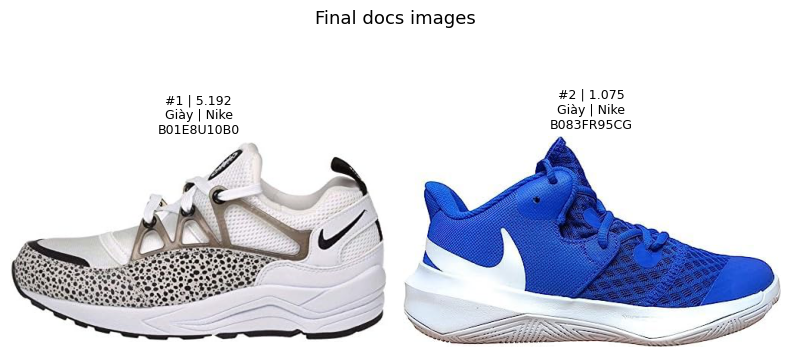

In [13]:
result = debug_layer_a_query("nike nữ giày thể thao màu trắng giá 3576000 đồng", use_bm25=True)
